#### Step 1. Open the data file and study the general information

In [9]:
# import libraies 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
from scipy import stats as st
from scipy.stats import ttest_ind

In [10]:
# Loading data 
df= pd.read_csv('/home/susan/videogame_sale_project/data/games.csv')
# make a  copy of data set 
videogame = df.copy()
print(videogame.info())
print('===='*30)
print()
print(videogame.columns)
print('===='*30)
print()
videogame.head()


<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  str    
 1   Platform         16715 non-null  str    
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  str    
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  str    
 10  Rating           9949 non-null   str    
dtypes: float64(6), str(5)
memory usage: 1.4 MB
None

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'NA_sales', 'EU_sales',
       'JP_sales', 'Other_sales', 'Critic_Score', 'User_Score', 'Rating'],
      dtype='str')



,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


#### Step2 : Prepare the data

In [11]:
# Replace the column names (make them lowercase).
videogame.columns = (videogame.columns.str.strip()
                                      .str.lower())
print(videogame.columns)
print('===='*30)
print()
# Convert the data to the required types.
videogame['user_score'] = pd.to_numeric(videogame['user_score'], errors='coerce')
print(videogame['user_score'].dtype)
print('===='*30)
print()
# check for missing data  
print(videogame.isna().sum())
print('===='*30)
print()
# After missing value, we you do inspection to find out in which row data is missing 
# from 'name'.isna()which missing data
print(videogame[videogame['name'].isna()].head())
print('='*100)
print()
# filing missing value with mean or zero,unknown if they are number column = colum .fillna()
#  Fix categorical missing values
videogame['genre'] = videogame['genre'].fillna('Unknown')
videogame['rating'] = videogame['rating'].fillna('Unknown')
print(videogame.isna().sum())               

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='str')

float64

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

      name platform  year_of_release genre  na_sales  eu_sales  jp_sales  \
659    NaN      GEN           1993.0   NaN      1.78      0.53      0.00   
14244  NaN      GEN           1993.0   NaN      0.00      0.00      0.03   

       other_sales  critic_score  user_score rating  
659           0.08           NaN         NaN    NaN  
14244         0.00           NaN         NaN    NaN  

name                  2
platform              0
year_of_release     269
genre                 0
na_sales              0
eu_sales              0
jp_

In [12]:
#Check for duplicated data
print(f'The number of duplicated values are : {videogame.duplicated().sum()}')


The number of duplicated values are : 0


======================================================
## Step 3. Analyze the data

**3.1 Look at how many games were released in different years. Is the data for every period significant?**
=======================================================

In [13]:
print(videogame['year_of_release'].describe())
print('='*100)

# Games per individual year (remove .head() to see all)
videogame_per_year = (videogame.groupby('year_of_release')['name']
                               .count()
                               .reset_index()
                               .rename(columns={'name': 'game_count'}))
print(videogame_per_year)
print('='*100)

# Games per PERIOD (what the question actually asks)
bins = [1980, 1990, 2000, 2010, 2020]
labels = ['1980s', '1990s', '2000s', '2010s']

videogame['period'] = pd.cut(videogame['year_of_release'], 
                              bins=bins, 
                              labels=labels, 
                              right=False)

videogame_per_period = (videogame.groupby('period')['name']
                                  .count()
                                  .reset_index()
                                  .rename(columns={'name': 'game_count'}))
print(videogame_per_period)


count    16446.000000
mean      2006.484616
std          5.877050
min       1980.000000
25%       2003.000000
50%       2007.000000
75%       2010.000000
max       2016.000000
Name: year_of_release, dtype: float64
    year_of_release  game_count
0            1980.0           9
1            1981.0          46
2            1982.0          36
3            1983.0          17
4            1984.0          14
5            1985.0          14
6            1986.0          21
7            1987.0          16
8            1988.0          15
9            1989.0          17
10           1990.0          16
11           1991.0          41
12           1992.0          43
13           1993.0          60
14           1994.0         121
15           1995.0         219
16           1996.0         263
17           1997.0         289
18           1998.0         379
19           1999.0         338
20           2000.0         350
21           2001.0         482
22           2002.0         829
23           2003.

**3.2 Look at how sales varied from platform to platform. Choose the platforms with the greatest total sales and build a distribution based on data for each year. Find platforms that used to be popular but now have zero sales. How long does it generally take for new platforms to appear and old ones to fade?**

*`What the Question is Actually Asking — 3 Parts`*

* Top platforms by total sales ← you did this ✅
* Sales distribution per year for top platforms (line chart)
* How long platforms rise and fade

Top platforms by lifetime sales:
   platform  sale_per_platforms
16      PS2             1255.77
28     X360              971.42
17      PS3              939.65
26      Wii              907.51
4        DS              806.12
15       PS              730.86
6       GBA              317.85
18      PS4              314.14
19      PSP              294.05
13       PC              259.52
   platform  year_of_release  total_sale
33      PS3           2016.0        3.60
44      Wii           2016.0        0.18
56     X360           2016.0        1.52
32      PS3           2015.0       16.82
43      Wii           2015.0        1.14


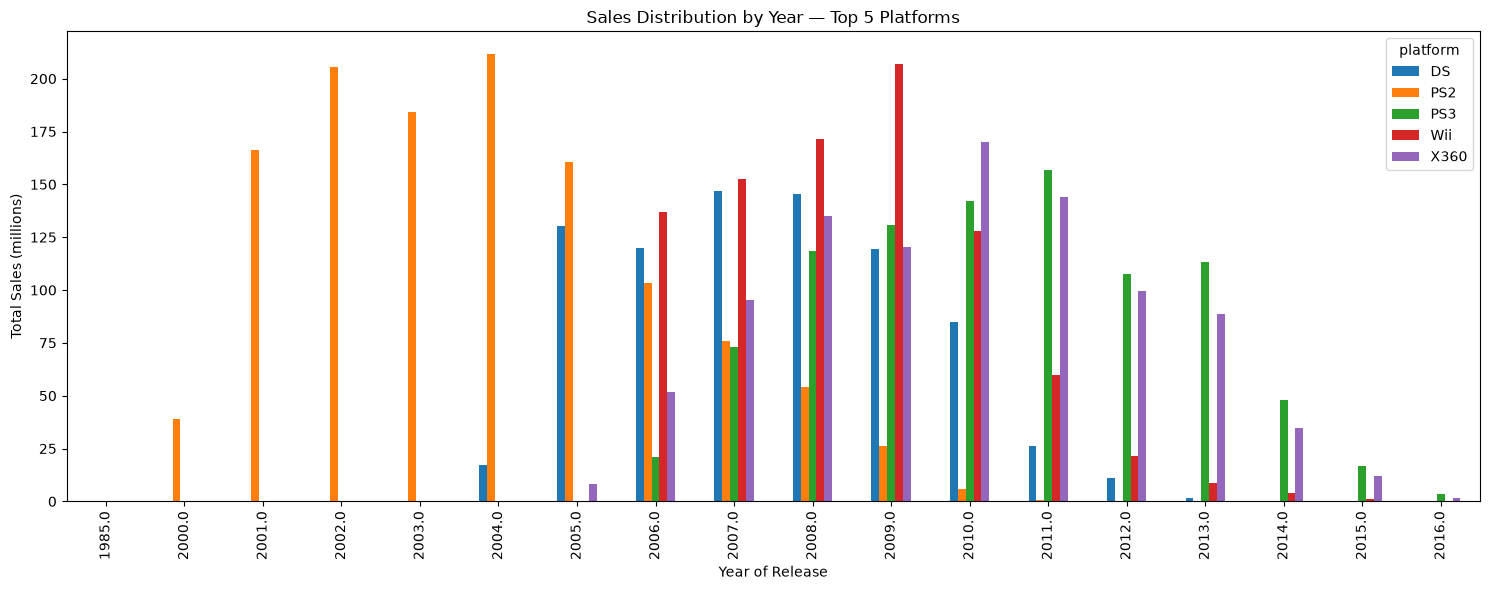

In [18]:
# platform and total sale
videogame['year_of_release'] = pd.to_numeric(videogame['year_of_release'], errors='coerce')
videogame['total_sale'] = (
    videogame['na_sales'] +
    videogame['eu_sales'] +
    videogame['jp_sales'] +
    videogame['other_sales']
)

platform_sales = (videogame.groupby('platform')['total_sale'].sum()
                            .reset_index()
                            .sort_values('total_sale', ascending=False)
                            .rename(columns={'total_sale': 'sale_per_platforms'})
                            .head(10))

print("Top platforms by lifetime sales:")
print(platform_sales)
print('===' * 30)

# PART 2 — Sales per year for TOP platforms
# tolist() converts pandas Series to a plain Python list
top_platforms = platform_sales['platform'].head(5).tolist()

# Filter original data to only those platforms
top_platform_data = videogame[videogame['platform'].isin(top_platforms)]

# Group by platform AND year
platform_year_sales = (
    top_platform_data
    .groupby(['platform', 'year_of_release'])['total_sale']
    .sum()
    .reset_index()
    .sort_values('year_of_release', ascending= False)
)

print(platform_year_sales.head())

# Pivot so each platform becomes its own column
platform_pivot = platform_year_sales.pivot(
    index='year_of_release',
    columns='platform',
    values='total_sale'
)

# Bar chart
platform_pivot.plot(
    kind='bar',
    title='Sales Distribution by Year — Top 5 Platforms',
    xlabel='Year of Release',
    ylabel='Total Sales (millions)',
    rot=90,
    figsize=(15, 6)
)

plt.tight_layout()
plt.show()



In [15]:
# How long does it generally take for new platforms to appear and old ones to fade?
print(videogame[['platform','year_of_release','total_sale']])
videogame['platform'].unique()
# For each platform, find:
# - first year it appeared
# - last year it had sales
# - how long it lasted

platform_lifespan = (videogame.groupby('platform')['year_of_release']
                               .agg(first_year='min', last_year='max')
                               .reset_index())

print('====='*30)
print(platform_lifespan)
platform_lifespan['lifespan_years'] = (platform_lifespan['last_year'] 
                                      - platform_lifespan['first_year'])

print(platform_lifespan.sort_values('first_year'))
print('===' * 30)
print(f"Average platform lifespan: {round(platform_lifespan['lifespan_years'].mean(), 1)} years")

      platform  year_of_release  total_sale
0          Wii           2006.0       82.54
1          NES           1985.0       40.24
2          Wii           2008.0       35.52
3          Wii           2009.0       32.77
4           GB           1996.0       31.38
...        ...              ...         ...
16710      PS3           2016.0        0.01
16711     X360           2006.0        0.01
16712      PSV           2016.0        0.01
16713      GBA           2003.0        0.01
16714      PSV           2016.0        0.01

[16715 rows x 3 columns]
   platform  first_year  last_year
0      2600      1980.0     1989.0
1       3DO      1994.0     1995.0
2       3DS      2011.0     2016.0
3        DC      1998.0     2008.0
4        DS      1985.0     2013.0
5        GB      1988.0     2001.0
6       GBA      2000.0     2007.0
7        GC      2001.0     2007.0
8       GEN      1990.0     1994.0
9        GG      1992.0     1992.0
10      N64      1996.0     2002.0
11      NES      1983.0   

==============================================================================================
**3.3**
* Determine what period you should take data for. To do so, look at your answers to the previous questions. 
The key criterion is that the data should allow you to build a prognosis for 2017(`You should not use all years. You should use only the years that are useful for predicting the next year, 2017.`)
* Work only with the data that you've decided is relevant. Disregard the data for previous years.
Which platforms are leading in sales? Which ones are growing or shrinking? Select several potentially profitable platforms.
=============================================================================================

<Axes: xlabel='platform'>

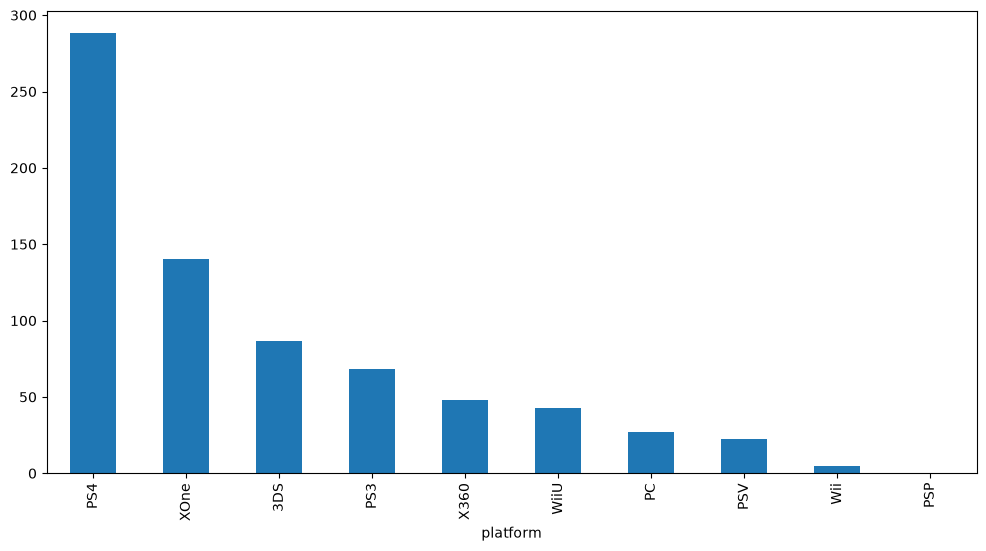

In [35]:
# Create filter 
videogame_pred = videogame[videogame['year_of_release']> 2013]

# Create groupby
platform_year_sales = (
    videogame_pred
    .groupby(['platform', 'year_of_release'])['total_sale']
    .sum()
    .reset_index()
    .sort_values(['platform', 'year_of_release'])
)

platform_sales = (
    videogame_pred
    .groupby('platform')['total_sale']
    .sum()
    .sort_values(ascending=False)
)
platform_sales.plot(kind='bar', figsize=(12, 6))







In [38]:
# Calculate platform sales by year and growth rates (%)
year_by_year_growth = (
    videogame_pred.groupby(['platform', 'year_of_release'])['total_sale']
    .sum()
    .reset_index()
    .pivot(index='platform', columns='year_of_release', values='total_sale')
    .fillna(0)
    .sort_index(axis=1)
)

# Convert year columns to integers for easier selection (e.g., 2014, 2015, 2016)
year_by_year_growth.columns = year_by_year_growth.columns.astype(int)

# Growth rate formula: ((new - old) / old) * 100
year_by_year_growth['growth_14_15'] = (
    (year_by_year_growth[2015] - year_by_year_growth[2014])
    / year_by_year_growth[2014].replace(0, np.nan)
    * 100
)

year_by_year_growth['growth_15_16'] = (
    (year_by_year_growth[2016] - year_by_year_growth[2015])
    / year_by_year_growth[2015].replace(0, np.nan)
    * 100
)

# View the platforms with the fastest recent growth
print(
    year_by_year_growth[['growth_14_15', 'growth_15_16']]
    .sort_values('growth_15_16', )
    .head(10)
)

year_of_release  growth_14_15  growth_15_16
platform                                   
PSP                -50.000000   -100.000000
X360               -65.572827    -87.290970
Wii                -69.600000    -84.210526
PS3                -64.782245    -78.596908
WiiU               -25.783023    -71.865443
XOne                11.226188    -56.518124
3DS                -36.517367    -45.500360
PS4                 18.900000    -41.757780
PC                 -35.843373    -38.380282
PSV                -47.478992    -32.000000


**3.4**
* Build a box plot for the global sales of all games, broken down by platform. Are the differences in sales significant? What about average sales on various platforms? Describe your findings.

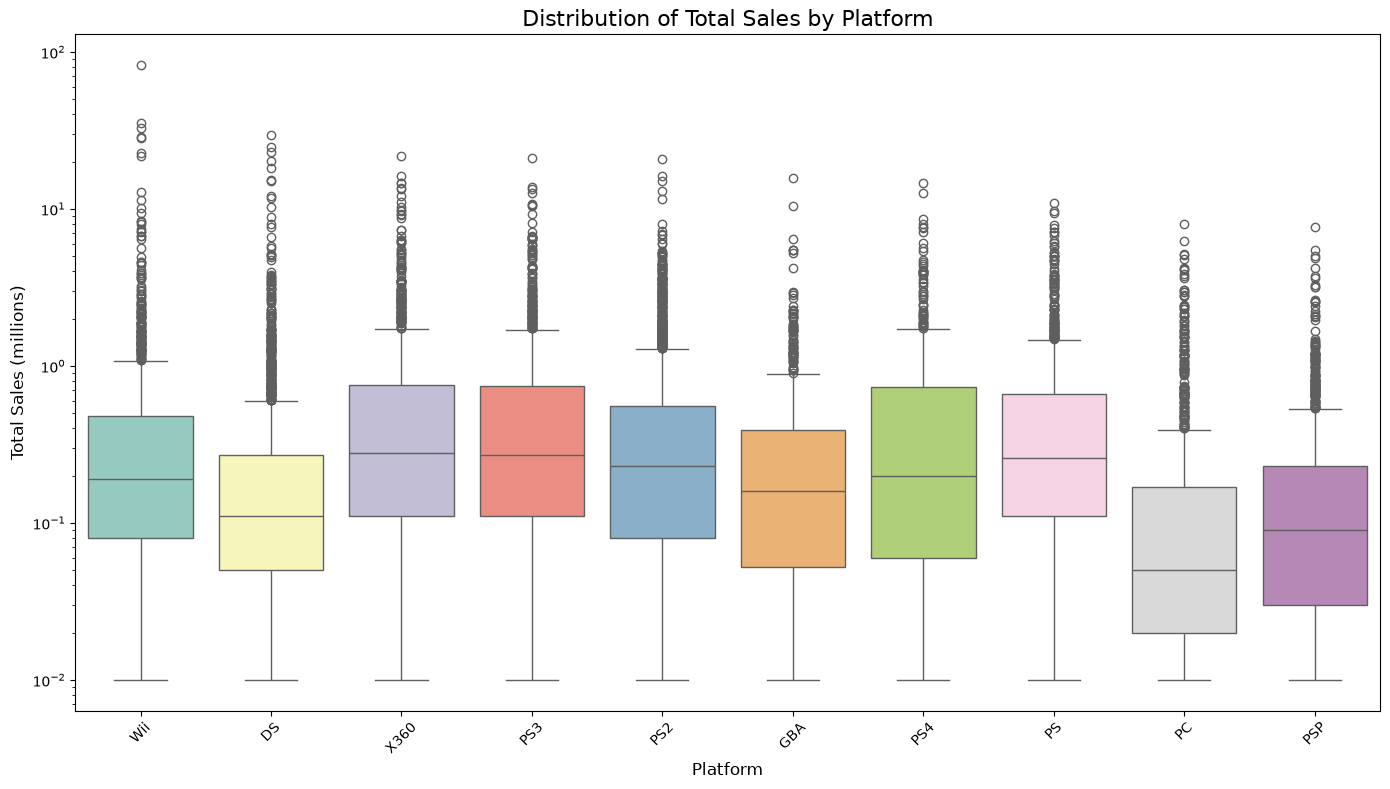

          count  mean  median    max
platform                            
PS4         392  0.80    0.20  14.63
X360       1262  0.77    0.28  21.82
PS3        1330  0.71    0.27  21.05
Wii        1320  0.69    0.19  82.54
PS         1197  0.61    0.26  10.95
PS2        2160  0.58    0.23  20.81
GBA         822  0.39    0.16  15.84
DS         2151  0.37    0.11  29.80
PC          974  0.27    0.05   8.01
PSP        1209  0.24    0.09   7.68


In [43]:
# Step 1: Build relevant dataframe
videogame_box = videogame[['platform', 'total_sale']].dropna().copy()

# Step 2: Keep top 10 platforms by lifetime sales for a cleaner x-axis
top10_platforms = (
    videogame_box.groupby('platform')['total_sale']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)
videogame_box = videogame_box[videogame_box['platform'].isin(top10_platforms)]

# Step 3: For log scale, keep only strictly positive sales
videogame_box = videogame_box[videogame_box['total_sale'] > 0]

# Step 4: Draw the box plot in your requested style
plt.figure(figsize=(14, 8))
sns.boxplot(
    x='platform',
    y='total_sale',
    data=videogame_box,
    hue='platform',
    palette='Set3',
    legend=False
    )
plt.title('Distribution of Total Sales by Platform', fontsize=16)
plt.xlabel('Platform', fontsize=12)
plt.ylabel('Total Sales (millions)', fontsize=12)
plt.xticks(rotation=45)
plt.yscale('log')  # Log scale improves visibility across very different sales values
plt.tight_layout()
plt.show()

# Step 5: Summary table to support interpretation
platform_summary = (
    videogame_box.groupby('platform')['total_sale']
    .agg(['count', 'mean', 'median', 'max'])
    .sort_values('mean', ascending=False)
    .round(2)
)
print(platform_summary)